In [2]:
import pandas as pd
print(pd.__version__)

3.0.5


In [3]:
scb = pd.read_csv("scb_unemployment_20232026.csv", sep=";", header = None, names =["month", "rate"])

In [4]:
af = pd.read_excel("abf_unemployment_20232026.xlsx", sheet_name ="abf", header =1)

In [5]:
scb.head()

,month,rate
0,2023M01,7.3
1,2023M02,7.3
2,2023M03,7.4
3,2023M04,7.4
4,2023M05,7.5


In [6]:
af.head()

,PERIOD,Totalt
0,2023-01-01,0.065
1,2023-02-01,0.065
2,2023-03-01,0.064
3,2023-04-01,0.063
4,2023-05-01,0.061


In [7]:
scb.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   month   43 non-null     str    
 1   rate    43 non-null     float64
dtypes: float64(1), str(1)
memory usage: 820.0 bytes


In [8]:
xls = pd.ExcelFile("abf_unemployment_20232026.xlsx")
print(xls.sheet_names)

['SQL-kod', 'abf', 'Info', 'Andel', 'Antal']


In [9]:
af.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   PERIOD   43 non-null     datetime64[us]
 1    Totalt  43 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 820.0 bytes


In [10]:
af.columns = af.columns.str.strip()

In [11]:
af["af_rate"] = af["Totalt"] * 100

In [12]:
print(af.columns)

Index(['PERIOD', 'Totalt', 'af_rate'], dtype='str')


In [13]:
scb["month"] = pd.to_datetime(scb["month"],format="%YM%m")

In [14]:
scb.head()

,month,rate
0,2023-01-01,7.3
1,2023-02-01,7.3
2,2023-03-01,7.4
3,2023-04-01,7.4
4,2023-05-01,7.5


In [15]:
af["Totalt"]=af["Totalt"]*100

In [16]:
af.head()

,PERIOD,Totalt,af_rate
0,2023-01-01,6.5,6.5
1,2023-02-01,6.5,6.5
2,2023-03-01,6.4,6.4
3,2023-04-01,6.3,6.3
4,2023-05-01,6.1,6.1


In [17]:
af = af.drop(columns=["Totalt"])

In [18]:
af.head()

,PERIOD,af_rate
0,2023-01-01,6.5
1,2023-02-01,6.5
2,2023-03-01,6.4
3,2023-04-01,6.3
4,2023-05-01,6.1


In [19]:
scb = scb.rename(columns={"month":"PERIOD","rate":"scb_rate"})

In [20]:
scb.head()

,PERIOD,scb_rate
0,2023-01-01,7.3
1,2023-02-01,7.3
2,2023-03-01,7.4
3,2023-04-01,7.4
4,2023-05-01,7.5


In [21]:
merged =pd.merge(scb,af,on ="PERIOD", how ="inner")

In [22]:
merged.head()

,PERIOD,scb_rate,af_rate
0,2023-01-01,7.3,6.5
1,2023-02-01,7.3,6.5
2,2023-03-01,7.4,6.4
3,2023-04-01,7.4,6.3
4,2023-05-01,7.5,6.1


In [23]:
merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   PERIOD    43 non-null     datetime64[us]
 1   scb_rate  43 non-null     float64       
 2   af_rate   43 non-null     float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 1.1 KB


In [24]:
merged.tail()

,PERIOD,scb_rate,af_rate
38,2026-03-01,8.7,6.6
39,2026-04-01,8.7,6.5
40,2026-05-01,8.7,6.4
41,2026-06-01,8.7,6.4
42,2026-07-01,8.7,6.5


In [25]:
len(merged)

43

In [26]:
merged.isna().sum()

PERIOD      0
scb_rate    0
af_rate     0
dtype: int64

In [27]:
merged["gap"] = merged["scb_rate"] - merged["af_rate"]

In [28]:
merged.head()

,PERIOD,scb_rate,af_rate,gap
0,2023-01-01,7.3,6.5,0.8
1,2023-02-01,7.3,6.5,0.8
2,2023-03-01,7.4,6.4,1.0
3,2023-04-01,7.4,6.3,1.1
4,2023-05-01,7.5,6.1,1.4


In [29]:
merged["gap"].describe()

count    43.000000
mean      1.686047
std       0.351582
min       0.800000
25%       1.500000
50%       1.700000
75%       1.900000
max       2.300000
Name: gap, dtype: float64

In [30]:
merged.loc[merged["gap"].idxmax()]

PERIOD      2026-05-01 00:00:00
scb_rate                    8.7
af_rate                     6.4
gap                         2.3
Name: 40, dtype: object

In [31]:
merged.loc[merged["gap"].idxmin()]

PERIOD      2023-01-01 00:00:00
scb_rate                    7.3
af_rate                     6.5
gap                         0.8
Name: 0, dtype: object

In [32]:
merged["month_num"] = merged["PERIOD"].dt.month

In [33]:
mean_gap_bymonth = merged.groupby("month_num")["gap"].mean()

In [34]:
mean_gap_bymonth

month_num
1     1.425000
2     1.425000
3     1.575000
4     1.725000
5     1.900000
6     1.875000
7     1.725000
8     1.666667
9     1.733333
10    1.766667
11    1.800000
12    1.666667
Name: gap, dtype: float64

In [35]:
merged["year"] = merged["PERIOD"].dt.year

In [36]:
merged.pivot(index ="month_num",
    columns="year",
    values="gap"
)

year,2023,2024,2025,2026
month_num,,,,
1,0.8,1.4,1.5,2.0
2,0.8,1.5,1.5,1.9
3,1.0,1.6,1.6,2.1
4,1.1,1.7,1.9,2.2
5,1.4,1.9,2.0,2.3
6,1.5,1.8,1.9,2.3
7,1.4,1.6,1.7,2.2
8,1.5,1.7,1.8,NaN
9,1.6,1.7,1.9,NaN


In [37]:
merged.groupby("year")["gap"].mean()

year
2023    1.316667
2024    1.650000
2025    1.825000
2026    2.142857
Name: gap, dtype: float64

In [38]:
def month_group(month):
    if 1 <= month <= 4:
        return "Jan-Apr"
    elif 5 <= month <= 11:
        return "May-Nov"
    else:
        return "Dec"

merged["period_group"] = merged["month_num"].apply(month_group)

In [39]:
merged[["PERIOD", "month_num", "period_group"]].head(15)

,PERIOD,month_num,period_group
0,2023-01-01,1,Jan-Apr
1,2023-02-01,2,Jan-Apr
2,2023-03-01,3,Jan-Apr
3,2023-04-01,4,Jan-Apr
4,2023-05-01,5,May-Nov
5,2023-06-01,6,May-Nov
6,2023-07-01,7,May-Nov
7,2023-08-01,8,May-Nov
8,2023-09-01,9,May-Nov
9,2023-10-01,10,May-Nov


In [40]:
gap_by_period = merged.pivot_table(
    index="period_group",
    columns="year",
    values="gap",
    aggfunc="mean"
)

In [41]:
gap_by_period

year,2023,2024,2025,2026
period_group,,,,
Dec,1.500000,1.500000,2.000000,NaN
Jan-Apr,0.925000,1.550000,1.625000,2.050000
May-Nov,1.514286,1.728571,1.914286,2.266667


In [42]:
gap_table = gap_by_period.T

In [43]:
gap_table

period_group,Dec,Jan-Apr,May-Nov
year,,,
2023,1.5,0.925,1.514286
2024,1.5,1.550,1.728571
2025,2.0,1.625,1.914286
2026,NaN,2.050,2.266667


In [44]:
gap_table["Difference JanApr and MayNov"] = (
    gap_table["May-Nov"] - gap_table["Jan-Apr"]
)

In [45]:
gap_table

period_group,Dec,Jan-Apr,May-Nov,Difference JanApr and MayNov
year,,,,
2023,1.5,0.925,1.514286,0.589286
2024,1.5,1.550,1.728571,0.178571
2025,2.0,1.625,1.914286,0.289286
2026,NaN,2.050,2.266667,0.216667


In [47]:
import matplotlib.pyplot as plt

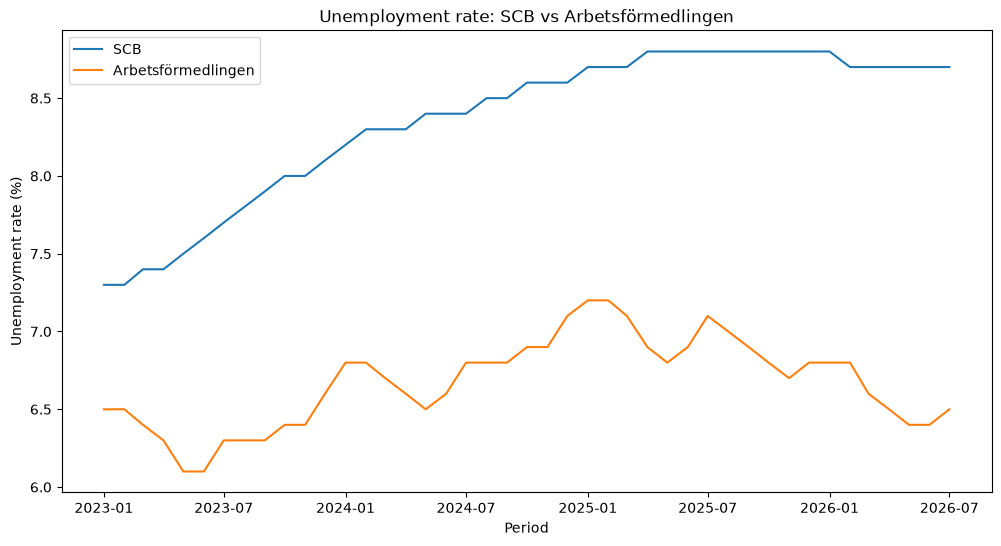

In [48]:
plt.figure(figsize=(12, 6))

plt.plot(merged["PERIOD"], merged["scb_rate"], label="SCB")
plt.plot(merged["PERIOD"], merged["af_rate"], label="Arbetsförmedlingen")

plt.xlabel("Period")
plt.ylabel("Unemployment rate (%)")
plt.title("Unemployment rate: SCB vs Arbetsförmedlingen")
plt.legend()

plt.show()

In [49]:
scb_icksasong = pd.read_csv("scb_unemployment_icksäsong2023-2026.csv", sep=";", header = None, names =["month", "rate"])

In [50]:
scb_icksasong.head()

,month,rate
0,2023M01,7.6
1,2023M02,8.2
2,2023M03,7.7
3,2023M04,7.5
4,2023M05,7.9


In [51]:
scb_icksasong["PERIOD"] = pd.to_datetime(scb_icksasong["month"], format ="%YM%m")

In [52]:
scb_icksasong.head()

,month,rate,PERIOD
0,2023M01,7.6,2023-01-01
1,2023M02,8.2,2023-02-01
2,2023M03,7.7,2023-03-01
3,2023M04,7.5,2023-04-01
4,2023M05,7.9,2023-05-01


In [53]:
scb_icksasong=scb_icksasong.drop(columns = "month")

In [54]:
scb_icksasong.head()

,rate,PERIOD
0,7.6,2023-01-01
1,8.2,2023-02-01
2,7.7,2023-03-01
3,7.5,2023-04-01
4,7.9,2023-05-01


In [55]:
scb_icksasong = scb_icksasong[["PERIOD", "rate"]]

In [56]:
scb_icksasong.head()

,PERIOD,rate
0,2023-01-01,7.6
1,2023-02-01,8.2
2,2023-03-01,7.7
3,2023-04-01,7.5
4,2023-05-01,7.9


In [57]:
scb_icksasong = scb_icksasong.rename(columns={"month":"PERIOD","rate":"scb_icksasong_rate"})

In [58]:
merged_icksasong = pd.merge(scb_icksasong,af,on = "PERIOD", how ="inner")

In [59]:
merged_icksasong.head()

,PERIOD,scb_icksasong_rate,af_rate
0,2023-01-01,7.6,6.5
1,2023-02-01,8.2,6.5
2,2023-03-01,7.7,6.4
3,2023-04-01,7.5,6.3
4,2023-05-01,7.9,6.1


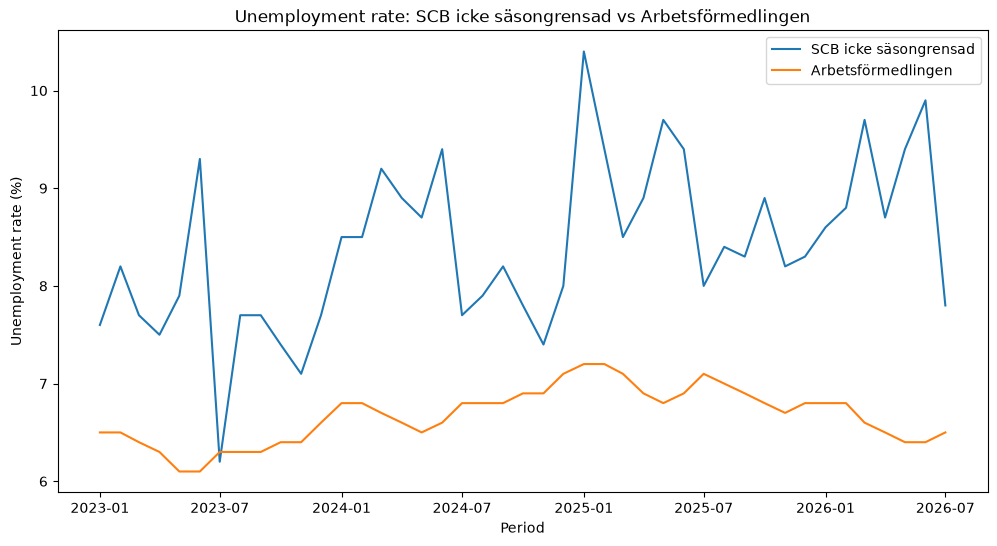

In [60]:
plt.figure(figsize=(12, 6))

plt.plot(merged_icksasong["PERIOD"], merged_icksasong["scb_icksasong_rate"], label="SCB icke säsongrensad")
plt.plot(merged_icksasong["PERIOD"], merged_icksasong["af_rate"], label="Arbetsförmedlingen")

plt.xlabel("Period")
plt.ylabel("Unemployment rate (%)")
plt.title("Unemployment rate: SCB icke säsongrensad vs Arbetsförmedlingen")
plt.legend()

plt.show()

In [61]:
merged_all = pd.merge(scb,merged_icksasong,on = "PERIOD", how ="inner")

In [62]:
merged_all.head()

,PERIOD,scb_rate,scb_icksasong_rate,af_rate
0,2023-01-01,7.3,7.6,6.5
1,2023-02-01,7.3,8.2,6.5
2,2023-03-01,7.4,7.7,6.4
3,2023-04-01,7.4,7.5,6.3
4,2023-05-01,7.5,7.9,6.1


In [63]:
merged_all = merged_all.rename(columns={
    "scb_rate_x": "scb_rate",
    "scb_rate_y": "scb_icksasong_rate"
})

In [64]:
merged_all.head()

,PERIOD,scb_rate,scb_icksasong_rate,af_rate
0,2023-01-01,7.3,7.6,6.5
1,2023-02-01,7.3,8.2,6.5
2,2023-03-01,7.4,7.7,6.4
3,2023-04-01,7.4,7.5,6.3
4,2023-05-01,7.5,7.9,6.1


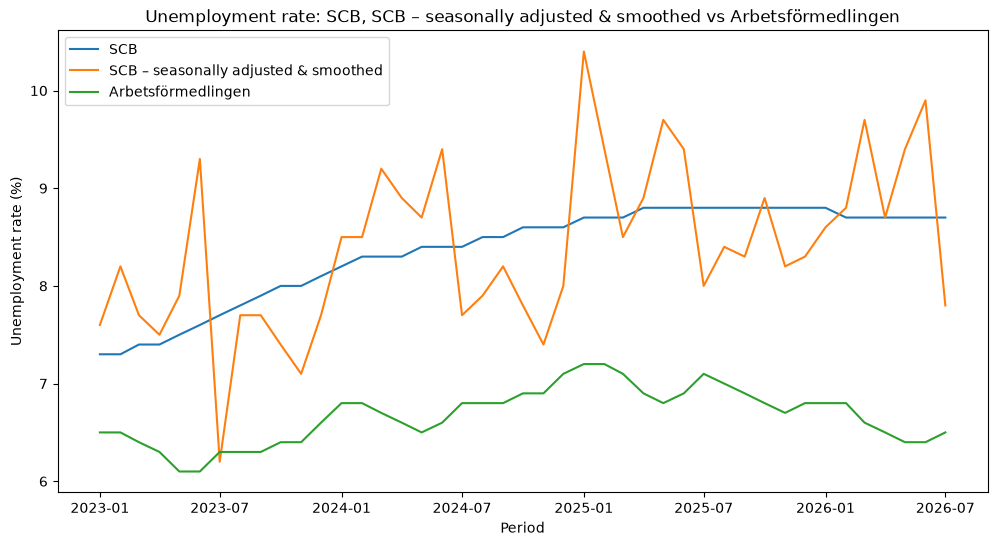

In [65]:
plt.figure(figsize=(12, 6))

plt.plot(merged_all["PERIOD"],merged_all["scb_rate"], label="SCB")
plt.plot(merged_all["PERIOD"], merged_all["scb_icksasong_rate"], label="SCB – seasonally adjusted & smoothed")
plt.plot(merged_all["PERIOD"], merged_all["af_rate"], label="Arbetsförmedlingen")
plt.xlabel("Period")
plt.ylabel("Unemployment rate (%)")
plt.title("Unemployment rate: SCB, SCB – seasonally adjusted & smoothed vs Arbetsförmedlingen")
plt.legend()

plt.show()

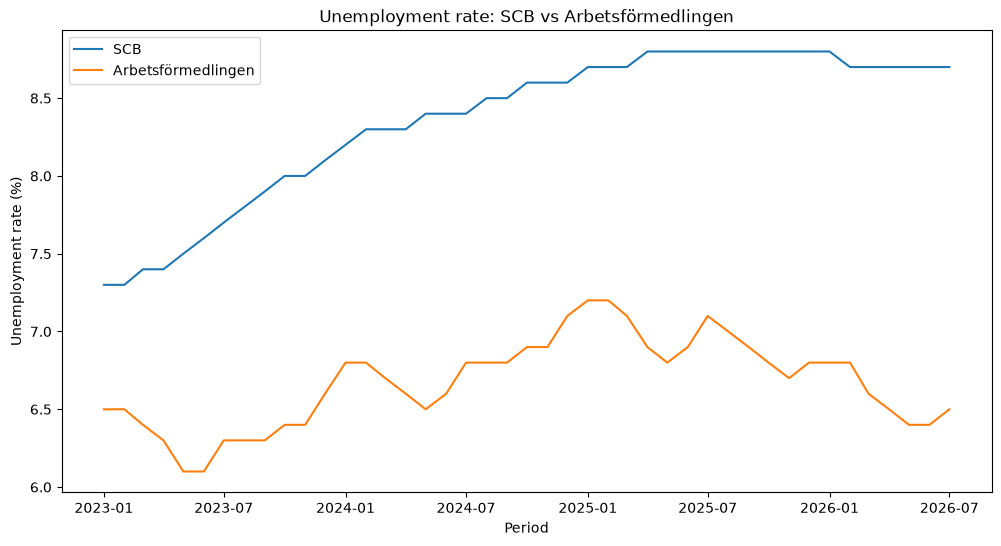

In [75]:
plt.figure(figsize=(12, 6))

plt.plot(merged_all["PERIOD"],merged_all["scb_rate"], label="SCB")
plt.plot(merged_all["PERIOD"], merged_all["af_rate"], label="Arbetsförmedlingen")
plt.xlabel("Period")
plt.ylabel("Unemployment rate (%)")
plt.title("Unemployment rate: SCB vs Arbetsförmedlingen")
plt.legend()

plt.show()

In [66]:
plt.savefig(
    "unemployment_rate_scb_af_2023_2026.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [67]:
merged_all["gap_adjusted"] = (
    merged_all["scb_rate"] - merged_all["af_rate"]
)

merged_all["gap_unadjusted"] = (
    merged_all["scb_icksasong_rate"] - merged_all["af_rate"]
)

In [68]:
merged_all.head()

,PERIOD,scb_rate,scb_icksasong_rate,af_rate,gap_adjusted,gap_unadjusted
0,2023-01-01,7.3,7.6,6.5,0.8,1.1
1,2023-02-01,7.3,8.2,6.5,0.8,1.7
2,2023-03-01,7.4,7.7,6.4,1.0,1.3
3,2023-04-01,7.4,7.5,6.3,1.1,1.2
4,2023-05-01,7.5,7.9,6.1,1.4,1.8


In [69]:
merged_all.head()

,PERIOD,scb_rate,scb_icksasong_rate,af_rate,gap_adjusted,gap_unadjusted
0,2023-01-01,7.3,7.6,6.5,0.8,1.1
1,2023-02-01,7.3,8.2,6.5,0.8,1.7
2,2023-03-01,7.4,7.7,6.4,1.0,1.3
3,2023-04-01,7.4,7.5,6.3,1.1,1.2
4,2023-05-01,7.5,7.9,6.1,1.4,1.8


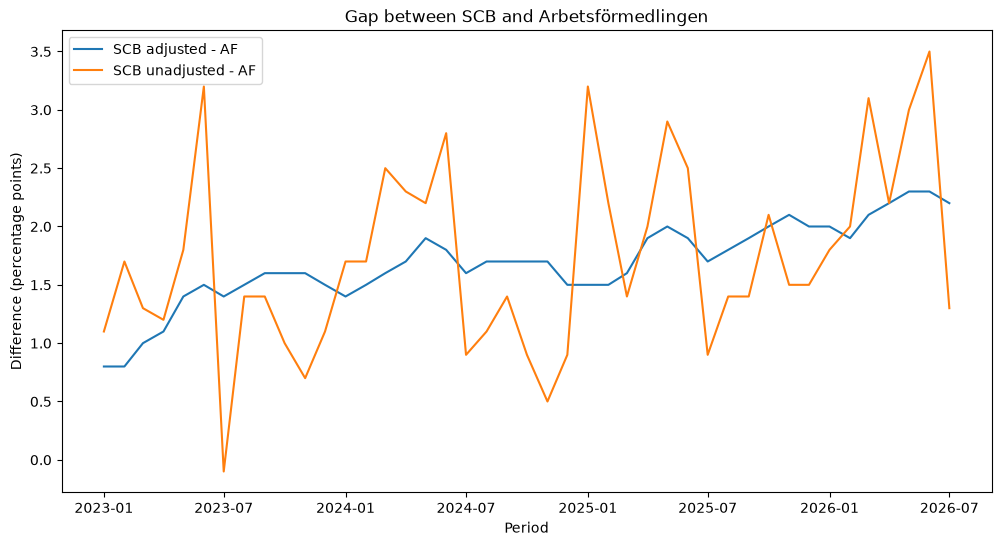

In [70]:
plt.figure(figsize=(12, 6))

plt.plot(
    merged_all["PERIOD"],
    merged_all["gap_adjusted"],
    label="SCB adjusted - AF"
)

plt.plot(
    merged_all["PERIOD"],
    merged_all["gap_unadjusted"],
    label="SCB unadjusted - AF"
)

plt.xlabel("Period")
plt.ylabel("Difference (percentage points)")
plt.title("Gap between SCB adjusted and SCB unadjusted")
plt.legend()

plt.savefig(
    "unemployment_gap_2023_2026.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [71]:
season_data = merged_all[
    merged_all["PERIOD"].dt.year <= 2025
].copy()

season_data["year"] = season_data["PERIOD"].dt.year
season_data["month_num"] = season_data["PERIOD"].dt.month

In [72]:
season_data["scb_dev"] = (
    season_data["scb_icksasong_rate"]
    - season_data.groupby("year")["scb_icksasong_rate"].transform("mean")
)

season_data["af_dev"] = (
    season_data["af_rate"]
    - season_data.groupby("year")["af_rate"].transform("mean")
)

In [73]:
season_profile = season_data.groupby("month_num")[
    ["scb_dev", "af_dev"]
].mean()

season_profile

,scb_dev,af_dev
month_num,,
1,0.538889,0.141667
2,0.405556,0.141667
3,0.172222,0.041667
4,0.138889,-0.091667
5,0.472222,-0.225000
6,1.072222,-0.158333
7,-0.994444,0.041667
8,-0.294444,0.008333
9,-0.227778,-0.025000


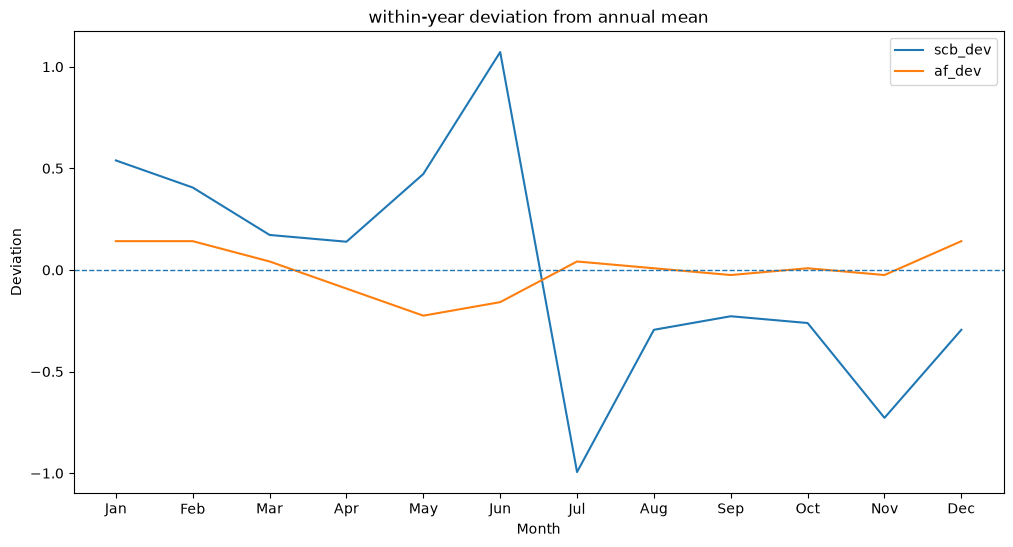

In [74]:
plt.figure(figsize=(12, 6))

plt.plot(
    season_profile.index,
    season_profile["scb_dev"],
    label="scb_dev"
)

plt.plot(
    season_profile.index,
    season_profile["af_dev"],
    label="af_dev"
)

plt.xlabel("Month")
plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
plt.ylabel("Deviation")
plt.title("within-year deviation from annual mean")
plt.legend()
plt.axhline(0, linewidth=1,linestyle="--")
plt.show()

In [76]:
merged_all["year"] = merged_all["PERIOD"].dt.year
merged_all["month"] = merged_all["PERIOD"].dt.month

jan_jul_raw = (
    merged_all[merged_all["month"] <= 7]
    .groupby("year")["gap_unadjusted"]
    .mean()
    .round(2)
)

print(jan_jul_raw)

year
2023    1.46
2024    2.01
2025    2.16
2026    2.41
Name: gap_unadjusted, dtype: float64


In [77]:
merged_all[
    ["PERIOD", "scb_icksasong_rate", "af_rate", "gap_unadjusted"]
].head()

,PERIOD,scb_icksasong_rate,af_rate,gap_unadjusted
0,2023-01-01,7.6,6.5,1.1
1,2023-02-01,8.2,6.5,1.7
2,2023-03-01,7.7,6.4,1.3
3,2023-04-01,7.5,6.3,1.2
4,2023-05-01,7.9,6.1,1.8
